# Regime Change Detection Feature Engineering

**Author:** Sergej Schweizer

**Description:** This notebook loads merged BTC spot and perpetual market data, engineers return and volatility features, and explores volatility regime behavior with plots.

In [1]:
# Import the libraries and helper used to load or generate the Deribit dataset.
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import numpy as np

from deribit_utils import generate_merged_deribit_dataset

In [2]:
# Load a local merged dataset when available, otherwise generate it through the Deribit helper.
csv_path = Path("merged_btc_data.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=["timestamp"])
else:
    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(days=365 * 5)
    df = generate_merged_deribit_dataset(
        base_asset="BTC",
        start_dt=start_dt,
        end_dt=end_dt,
        ohlcv_resolution="60",
        funding_resolution="8h",
        spot_chunk_days=7,
        perp_chunk_days=7,
        funding_chunk_days=30,
        save_csv=True,
        csv_path=str(csv_path),
    ).reset_index()

# Use timestamp as the index so rolling features align naturally over time.
df.set_index("timestamp", inplace=True)
# Inspect a small sample to confirm the dataset loaded as expected.
df.sample(3)

,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,volume_perp,cost_perp,index_price,interest_8h,interest_1h,prev_index_price
timestamp,,,,,,,,,,,,,,,,
2025-05-26 11:00:00+00:00,109641.0,109829.0,109641.0,109785.0,4.0004,438823.9316,109737.5,109906.0,109665.0,109850.0,60.027028,6588280.0,109684.39,0.000085,1.631793e-05,109756.62
2025-10-13 04:00:00+00:00,114929.0,114997.0,114482.0,114716.0,1.5533,178202.0399,114934.5,115117.5,114508.5,114813.5,347.518423,39903050.0,114930.43,0.000027,1.126768e-08,115432.64
2025-01-23 00:00:00+00:00,103786.0,103786.0,103204.0,103220.0,0.3215,33313.7938,103689.5,103802.0,103035.5,103287.5,332.686960,34398510.0,103655.56,0.000010,2.673062e-06,103829.52


In [3]:
# Compute log returns plus absolute and squared features for the core price series.
df = df.assign(
    # Spot close-to-close log return.
    return_close_spot=lambda x: np.log(x["close_spot"] / x["close_spot"].shift(1)),
    # Perpetual close-to-close log return.
    return_close_perp=lambda x: np.log(x["close_perp"] / x["close_perp"].shift(1)),
    # Index price log return.
    return_index_price=lambda x: np.log(x["index_price"] / x["index_price"].shift(1)),
    # Absolute spot return as a simple volatility proxy.
    abs_return_close_spot=lambda x: x["return_close_spot"].abs(),
    # Absolute perpetual return as a simple volatility proxy.
    abs_return_close_perp=lambda x: x["return_close_perp"].abs(),
    # Absolute index return as a simple volatility proxy.
    abs_return_index_price=lambda x: x["return_index_price"].abs(),
    # Squared spot return for variance-style features.
    sq_return_close_spot=lambda x: x["return_close_spot"] ** 2,
    # Squared perpetual return for variance-style features.
    sq_return_close_perp=lambda x: x["return_close_perp"] ** 2,
    # Squared index return for variance-style features.
    sq_return_index_price=lambda x: x["return_index_price"] ** 2,
)

In [4]:
# Define the return-based features for which rolling volatility will be calculated.
return_cols = [
    "return_close_spot",
    "return_close_perp",
    "return_index_price",
    "abs_return_close_spot",
    "abs_return_close_perp",
    "abs_return_index_price",
    "sq_return_close_spot",
    "sq_return_close_perp",
    "sq_return_index_price",
]

# Use 24 and 72 hourly observations as short- and medium-horizon rolling windows.
window_24h = 24
window_72h = 72

# Add rolling standard deviation features for each return-derived series.
df = df.assign(
    **{
        f"std_24h_{col}": df[col].rolling(window_24h).std()
        for col in return_cols
    },
    **{
        f"std_72h_{col}": df[col].rolling(window_72h).std()
        for col in return_cols
    },
)

In [5]:
# Build true-range-based ATR features for spot and perpetual BTC markets.
df = df.assign(
    # Spot true range uses the largest move among intraperiod range and gaps from the previous close.
    tr_spot=pd.concat(
        [
            df["high_spot"] - df["low_spot"],
            (df["high_spot"] - df["close_spot"].shift(1)).abs(),
            (df["low_spot"] - df["close_spot"].shift(1)).abs(),
        ],
        axis=1,
    ).max(axis=1),
    # Perpetual true range applies the same definition to perpetual futures prices.
    tr_perp=pd.concat(
        [
            df["high_perp"] - df["low_perp"],
            (df["high_perp"] - df["close_perp"].shift(1)).abs(),
            (df["low_perp"] - df["close_perp"].shift(1)).abs(),
        ],
        axis=1,
    ).max(axis=1),
).assign(
    # Convert true range into 24h and 72h ATR levels, then normalize by price for comparability.
    ATR_24h_spot=lambda x: x["tr_spot"].rolling(24).mean(),
    ATR_72h_spot=lambda x: x["tr_spot"].rolling(72).mean(),
    ATR_24h_spot_norm=lambda x: x["ATR_24h_spot"] / x["close_spot"],
    ATR_72h_spot_norm=lambda x: x["ATR_72h_spot"] / x["close_spot"],
    ATR_24h_perp=lambda x: x["tr_perp"].rolling(24).mean(),
    ATR_72h_perp=lambda x: x["tr_perp"].rolling(72).mean(),
    ATR_24h_perp_norm=lambda x: x["ATR_24h_perp"] / x["close_perp"],
    ATR_72h_perp_norm=lambda x: x["ATR_72h_perp"] / x["close_perp"],
).drop(columns=["tr_spot", "tr_perp"])

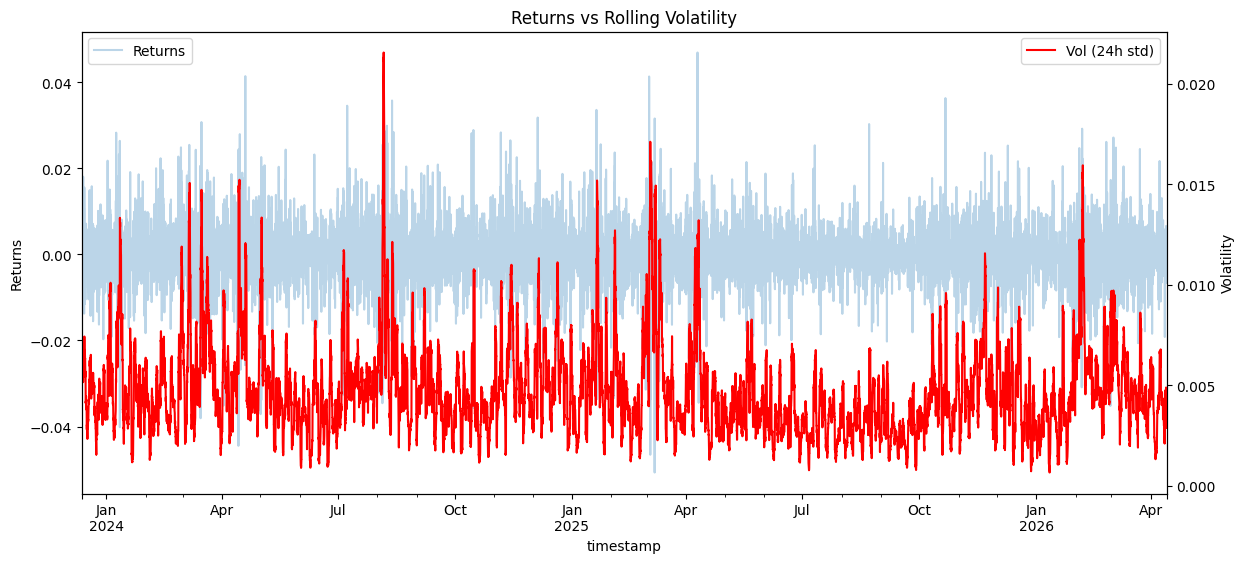

In [ ]:
# Plot spot returns against rolling 24-hour volatility to compare price moves with their local variability.
import matplotlib.pyplot as plt

ax1 = df["return_close_spot"].plot(
    figsize=(14, 6),
    alpha=0.3,
    label="Returns",
    ylabel="Returns",
)

ax2 = df["std_24h_return_close_spot"].plot(
    ax=ax1.twinx(),
    color="red",
    label="Vol (24h std)",
    ylabel="Volatility",
)

ax1.set_title("Returns vs Rolling Volatility")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

Text(0, 0.5, 'Regime')

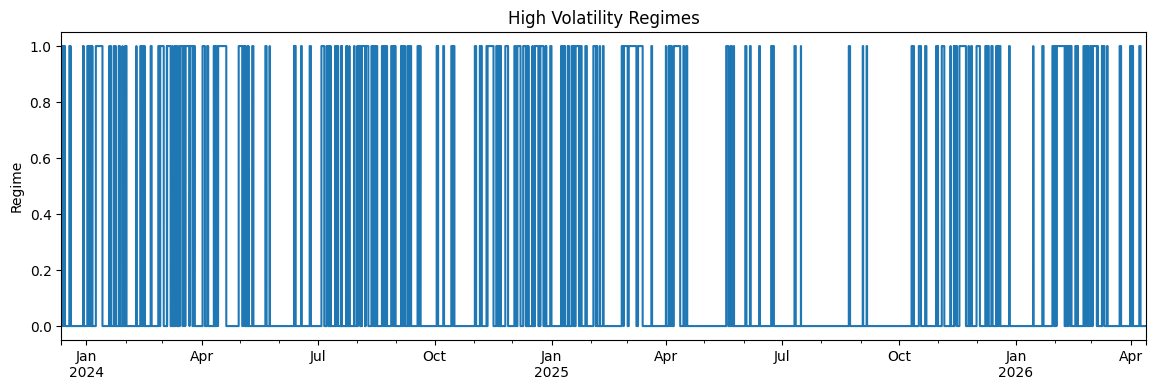

In [ ]:
# Label timestamps as high-volatility regimes when 24-hour rolling volatility exceeds its upper quartile.
vol = df["std_24h_return_close_spot"]
threshold = vol.quantile(0.75)

df["high_vol"] = (vol > threshold).astype(int)

ax = df.plot(
    y="high_vol",
    figsize=(14, 4),
    drawstyle="steps",
    title="High Volatility Regimes",
    legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Regime")

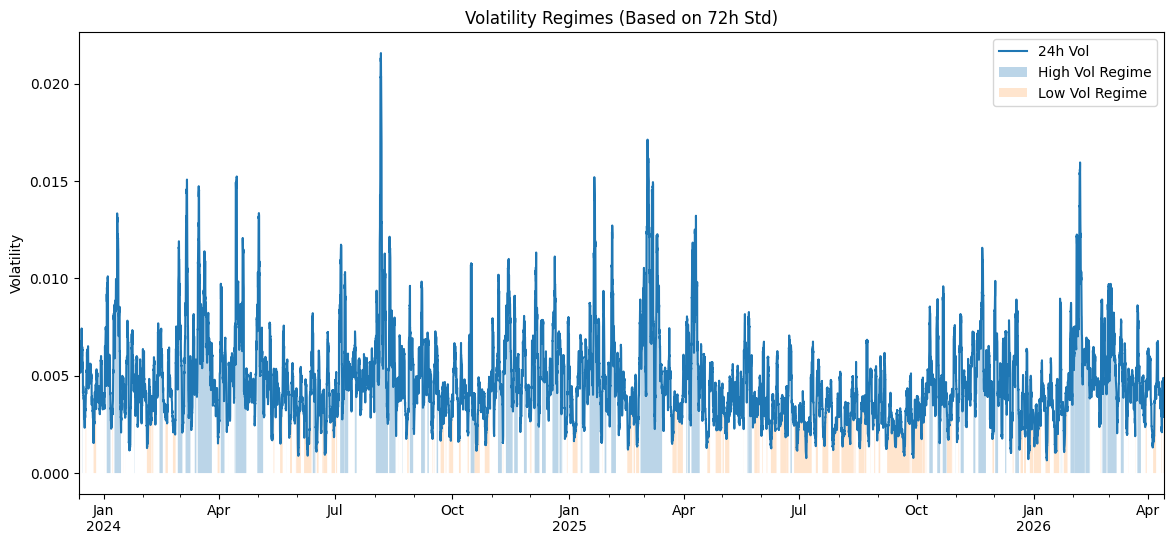

In [ ]:
# Highlight high- and low-volatility periods using the 72-hour volatility measure as the regime signal.
vol = df["std_72h_return_close_spot"]
high = vol > vol.quantile(0.75)
low = vol < vol.quantile(0.25)

ax = df.plot(
    y="std_24h_return_close_spot",
    figsize=(14, 6),
    label="24h Vol",
    title="Volatility Regimes (Based on 72h Std)",
)

ax.fill_between(
    df.index,
    0,
    df["std_24h_return_close_spot"],
    where=high,
    alpha=0.3,
    label="High Vol Regime",
)

ax.fill_between(
    df.index,
    0,
    df["std_24h_return_close_spot"],
    where=low,
    alpha=0.2,
    label="Low Vol Regime",
)

ax.set_xlabel("")
ax.set_ylabel("Volatility")
ax.legend()